In [15]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt

# Ensemble methods
- voting classifiers
- baggin and pasting ensembles
- random forests
- boosting
- stacking ensembles

### Voting classifier

__Hard voting__ or majority voting vs __Soft voting__ - the classifier with the highest class probability gets the vote


Text(0.5, 1.0, 'Coin tosses biased coin')

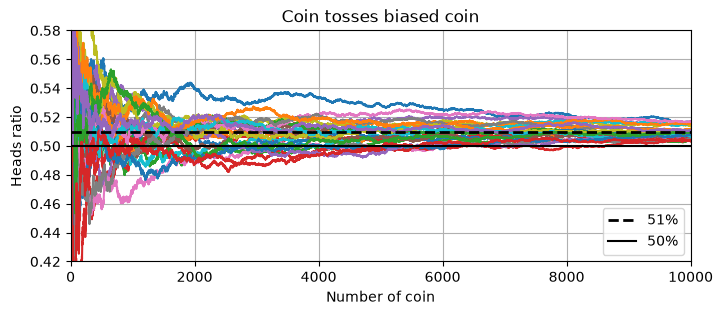

In [9]:
import numpy as np
import matplotlib.pyplot as plt

heads_proba=0.51
rng = np.random.default_rng(seed=42)
coin_tosses = (rng.random((10_000,25)) < heads_proba).astype(np.int32)
cumulative_heads = coin_tosses.cumsum(axis=0)
cumulative_heads_ratio = cumulative_heads / np.arange(1,10_001).reshape(-1,1)

plt.figure(figsize=(8,3))
plt.plot(cumulative_heads_ratio)
plt.plot([0,10_000], [0.51,0.51], "k--", label="51%", linewidth=2)
plt.plot([0,10_000], [0.5, 0.5], "k-", label="50%")
plt.xlabel("Number of coin")
plt.ylabel("Heads ratio")
plt.axis([0,10_000, 0.42, 0.58])
plt.grid()
plt.legend(loc="lower right")
plt.title("Coin tosses biased coin")
           

In [17]:
X,y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

In [19]:
voting_clf = VotingClassifier(
    estimators = [
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc',SVC(random_state=42))
    ]
)
voting_clf.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...ndom_state=42), RandomForestC...ndom_state=42), SVC(random_state=42)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,2


The original estimators are available via the `estimators`/`named_estimators` attribute, while the fitted clones used are available via `estimators_`/`named_estimators_`

In [23]:
for name, clf in voting_clf.named_estimators_.items():
    print(f'{name} = {clf.score(X_test, y_test)}')

lr = 0.864
rf = 0.896
svc = 0.896


In [21]:
voting_clf.score(X_test,y_test)

0.912

In [24]:
voting_clf.estimators_

[LogisticRegression(random_state=42),
 RandomForestClassifier(random_state=42),
 SVC(random_state=42)]

In [27]:
voting_clf.predict(X_test[:1]), y_test[:1]

(array([1]), array([1]))

2/3 of the classes voted '1' for the first instance of the test set:

In [28]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([1]), array([0])]

#### Soft voting
We set the `voting` hyperparam to "soft"

In [29]:
voting_clf.voting="soft"
voting_clf.named_estimators["svc"].probability=True  #svc does not estimate class probabilities by default so need to set it explicitly before hand
voting_clf.fit(X_train,y_train)
voting_clf.score(X_test, y_test)

/home/sam/Dev/ai_ml/ageron/scikitenv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


0.92

In [37]:
voting_clf.estimators[2] = ('csvc', CalibratedClassifierCV(SVC(random_state=42),method="isotonic", cv=5))
voting_clf.fit(X_train,y_train)
voting_clf.score(X_test,y_test)

0.928

### Bagging and Pasting
Use the same model but train on different random subsets. Sampling can be done with replacement(_bagging_) or without (_pasting_).
Once all predictors are trained, the ensemble can make a new prediction by aggregating the predictions of all predictors, typically using the _mode_ (in classification) or the _average_ (in regression).  

This ensemble method usually ends up with a similar bias but a lower variance than a single predictor so it works best with high-variance and low bias models (e.g ensemble of decision trees, not ensemble of linear regressors)

__Prefer bagging when your dataset is noisy or your model is prone to overfitting, otherwise prefer pasting.__   
Predictors can be trained in parallel via different CPU cores or different servers. 

`BaggingClassifier` supports feature sampling as well.


In [38]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=100, n_jobs=-1, random_state=42) #n_jobs=-1 - use All CPU cores
#set bootstrap=False to do pasting instead but Bagging is preferred since it introduces more diversity in the subsets making predictors less correlated
bag_clf.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",100
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [39]:
bag_clf.score(X_test, y_test)

0.904

##### Out-of-bag instances
On average about 37% of training instances are not sampled, for each predictor. These oob instances can be used to make 
a fair evaluation set for the ensemble predictor:

In [40]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, oob_score=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_  #the evaluation score


0.896

In [41]:
bag_clf.score(X_test, y_test)

0.92

In [43]:
bag_clf.oob_decision_function_[:3]

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

So far we have the following hyperparameters:
- `n_estimators` - the number of base estimators to use in the ensemble
- `bootstrap`  (set to _false_ to sample without replacement i.e pasting)
- `max_samples` - set the sample size to train each base estimator
-  `bootstrap_features` - set to _True_ to also sample features
-  `max_features` - set feature size for each estimator in the feature sampling
-  `oob_score` - set to _True_ to use out-of-bag samples to estimate the generalization (validation) error (only when bagging not pasting)
-  `n_jobs` - Number of CPU cores to use for training and rpedictions (-1 tells sklearn to use all available cores)

### Random Forests
An ensemble of decision trees, generally trained via bagging typically with `max_samples` set to the size of the training set?? and `max_features` equal to $\sqrt{n}$ features. Random Forest classes and Decision Tree classes in Scikit-Learn support missing values natively, so no need for an Imputer

In [45]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, random_state=42)
rnd_clf.fit(X_train,y_train)
rnd_clf.score(X_test, y_test)

#can also set splitter="random" to use random threshold instead of the best possible threshold

0.912

In [6]:
#Equivalent to
bag_clf = BaggingClassifier( DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes =16), n_estimators=500,
                                                    n_jobs=-1, random_state=42)
bag_clf.fit(X_train,y_train)
bag_clf.score(X_test,y_test)
                            

0.912

##### Extremely randomized trees
For decision trees you can set `splitter=random` to use random threshold. A forest of such trees is an extremely randomized tree or _extra tree_. Use scikit learn's `ExtraTreesClassifier` class. It trades more bias for lower variance (so may perform better if you encounter overfitting)

### Feature Importance with Random Forests
sklearn measures a feature's importance by looking at how much the tree nodes that use that feature reduce impurity on average across all trees in the forest:
A weighted average where each node's weight is equal to the number of training samples in that node. Scikit learn calculates the score for each feature then scales the results so the sum of all importances =1

In [9]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)
for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(round(score,2), name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


Let's visualize feature importance in the mnist digits dataset (features are the 784 pixel points)

In [ ]:
from sklearn.datasets import fetch_openml
X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False, parser='auto')
rnd_clf= RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(X_mnist, y_mnist)
heatmap_image = rnd_clf.feature_importances_.reshape(28,28)


In [14]:
rnd_clf.feature_importances_.shape

(784,)

[Text(1, 0.0, 'Not important'),
 Text(1, 0.009791489757332336, 'Very important')]

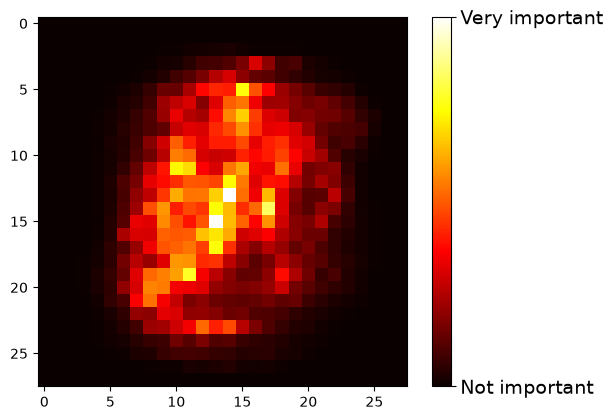

In [16]:
plt.imshow(heatmap_image, cmap="hot")
cbar = plt.colorbar(ticks=[rnd_clf.feature_importances_.min(), rnd_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Not important', 'Very important'], fontsize=14)

## Stacking
In stacking we train a model to decide the aggregation of predictor results (instead of hard or soft voting).
The final predictor is called a Blender

In [18]:
from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(
    estimators = [
        ('lr', LogisticRegression(random_state=42)),
        ('rf',RandomForestClassifier(random_state=42)),
        ('svc',SVC(probability=True, random_state=42))
    ],
    final_estimator=RandomForestClassifier(random_state=42),
    cv=5 
)
stacking_clf.fit(X_train, y_train)

/home/sam/Dev/ai_ml/ageron/scikitenv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sam/Dev/ai_ml/ageron/scikitenv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sam/Dev/ai_ml/ageron/scikitenv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/sam/Dev/ai_ml/ageron/scikitenv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning:

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('rf', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",RandomForestC...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[LogisticRegre...ndom_state=42), RandomForestC...ndom_state=42), SVC(probabili...ndom_state=42)]"
final_estimator_ final_estimator_: estimatorThe classifier fit on the output of `estimators_` and responsible forfinal predictions.,RandomForestClassifier,RandomForestC...ndom_state=42)


In [19]:
stacking_clf.score(X_test,y_test)

0.912